# Session 04 — Exploratory visualization

Revision ID: S04-r1

**Question:** What do plots of incident resolution times show that a table of means and standard deviations can hide?

## Learning outcomes

1. Match a plot to variable type and exploratory question.
2. Build and interpret bar charts, histograms, and boxplots with readable labels and counts.
3. Describe shape, coverage, and unusual values without automatically calling them errors.
4. Communicate visual evidence and limitations without causal claims.

## Workflow and data

Run cells in order. The exact CC0 synthetic CSV is embedded for offline use. One fictional closed incident is the observational unit. `resolution_hours` measures opening-to-closure time in hours, not response latency. The raw export has 25 rows; follow the documented Session 2 cleaning policy and keep the raw table unchanged. The data are not random, causal, or time-indexed. Do not use incident ID as a time axis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

csv_text = """incident_id,service,severity,resolution_hours,deploy_version,customer_impact
INC-001,api,low,2,v1,no
INC-002,web,medium,5,v1,yes
INC-003,worker,high,8,v1,no
INC-004,api,low,3,v1,yes
INC-005,web,medium,,v1,no
INC-006,worker,high,12,v1,yes
INC-007,api,low,4,v1,no
INC-008,web,medium,-2,v1,yes
INC-009,worker,high,9,v1,no
INC-010,api,low,2,v1,yes
INC-011,,medium,8,v1,no
INC-012,worker,high,15,v1,yes
INC-013,api,low,3,v2,no
INC-014,web,medium,6,v2,yes
INC-015,worker,high,10,v2,no
INC-016,api,low,4,v2,yes
INC-017,web,medium,,v2,no
INC-018,worker,high,18,v2,yes
INC-019,api,low,5,v2,no
INC-020,web,medium,10,v2,yes
INC-021,worker,high,14,v2,no
INC-022,api,low,6,v2,yes
INC-023,web,medium,11,v2,no
INC-024,worker,high,24,v2,yes
INC-003,worker,high,8,v1,no
"""
raw = pd.read_csv(StringIO(csv_text))
raw_snapshot = raw.copy(deep=True)
clean = raw.drop_duplicates().copy()
clean.loc[clean["resolution_hours"] < 0, "resolution_hours"] = float("nan")
clean["service"] = clean["service"].fillna("unknown")
assert raw.equals(raw_snapshot)
assert len(clean) == 24 and clean["resolution_hours"].count() == 21
observed = clean.dropna(subset=["resolution_hours"])
print(f"Distinct incidents: {len(clean)}; observed durations: {len(observed)}")

Distinct incidents: 24; observed durations: 21


## S04-E1

Create a histogram of the observed `resolution_hours` values. Label the horizontal axis in hours, label the vertical axis as incident count, include the observed n in the title, and write one cautious sentence about the shape.

In [2]:
fig, ax = None, None
# TODO: make a labeled histogram from observed['resolution_hours'] and include n in the title.

## S04-E2

Create a bar chart comparing incident-record counts and observed `resolution_hours` counts by service. Add a legend and axis labels. Write one sentence explaining why both counts belong in the figure.

In [3]:
counts = None
# TODO: group by service; use size for incident records and count for observed durations, then plot both columns.

## S04-E3

Create a boxplot of observed resolution hours by service and overlay the individual values. Label hours and groups. Write one observation and one caution about small or unequal observed counts.

In [4]:
fig, ax = None, None
# TODO: make a labeled boxplot by service and overlay every observed value.

## Interpret and communicate

For each plot, state what is visible and one limitation. Name the variable and unit, and include the observed count. The figures describe the available synthetic records; they do not recover missing times or establish a causal effect.

## Synthesis

Use bars for categories, histograms for numerical distributions, and grouped boxplots with points to inspect small groups. Label axes and denominators. A connected line requires meaningful time order; an incident ID does not supply one.

## Readings

- [Learning Statistics with Python, Chapter 6](https://ethanweed.github.io/pythonbook/06.00-visualisation.html)
- [Think Stats, Chapter 1](https://allendowney.github.io/ThinkStats/chap01.html)
- [Matplotlib histogram](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)
- [Matplotlib boxplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)


## Choose a chart by variable type and question

Use bar charts for category counts, histograms for numerical distributions, and grouped boxplots with points for a numerical measure across categories. A scatterplot needs two meaningful numerical variables; a line plot needs a meaningful time order. Avoid pie charts for ordered categories, and do not treat a coded label as a measurement.

## Categorical by categorical: version and recorded impact

A contingency table and grouped bars summarize counts for two categorical variables. The records are observational: the display describes this export and cannot isolate a version effect.

customer_impact,no,yes
deploy_version,,
v1,6,6
v2,6,6


customer_impact,no,yes
deploy_version,,
v1,0.5,0.5
v2,0.5,0.5


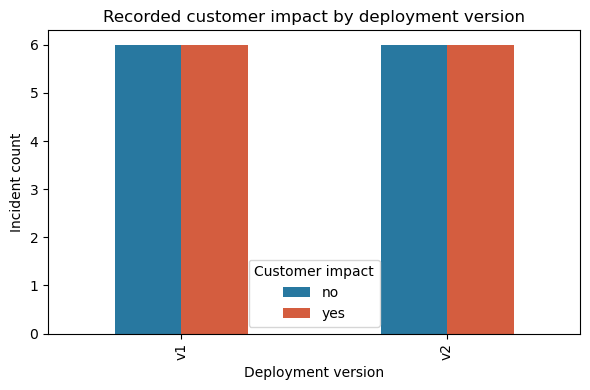

In [5]:
impact_counts = pd.crosstab(clean["deploy_version"], clean["customer_impact"])
display(impact_counts)
display(pd.crosstab(clean["deploy_version"], clean["customer_impact"], normalize="index").round(2))
ax = impact_counts.plot(kind="bar", figsize=(6, 4), color=["#2878a0", "#d45d3f"])
ax.set(title="Recorded customer impact by deployment version", xlabel="Deployment version", ylabel="Incident count")
ax.legend(title="Customer impact")
plt.tight_layout()
plt.show()

## Optional two-variable example: daily stock data

The incident dataset has only one numerical measure, so it cannot support a meaningful scatterplot. Matplotlib bundles a local Google stock-price sample with dates, closing prices, and trading volume. The example below uses a line plot for date order and a scatterplot for two numerical measurements recorded on the same day. It covers 2004–2008, not current market conditions.

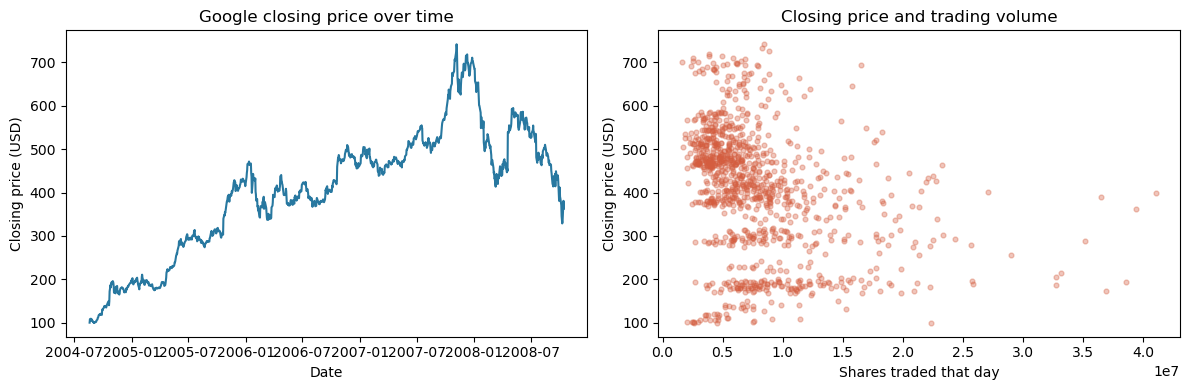

Rows: 1047 Date range: 2004-08-19 00:00:00 to 2008-10-14 00:00:00


In [6]:
import numpy as np
from matplotlib.cbook import get_sample_data

with np.load(get_sample_data("goog.npz", asfileobj=False)) as sample:
    stock_data = sample["price_data"]
google = pd.DataFrame({
    "date": stock_data["date"],
    "close_usd": stock_data["close"],
    "volume_shares": stock_data["volume"],
})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(google["date"], google["close_usd"], color="#2878a0")
axes[0].set(title="Google closing price over time", xlabel="Date", ylabel="Closing price (USD)")
axes[1].scatter(google["volume_shares"], google["close_usd"], s=12, alpha=0.35, color="#d45d3f")
axes[1].set(title="Closing price and trading volume", xlabel="Shares traded that day", ylabel="Closing price (USD)")
fig.tight_layout()
plt.show()
print("Rows:", len(google), "Date range:", google["date"].min(), "to", google["date"].max())